https://confident-reflection-production-d304.up.railway.app/api/admin/extract-all?token=CHOCOLATCOGNITIF


### Extraction of the data and DataFrame construction

In [2]:
from pathlib import Path
import json
import pandas as pd

rows = []

for file in Path("archives").rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for trial in data["resultats"]:
        if trial.get("task") != "target":
            continue

        participant_id = trial["participant_id"]
        rt = trial["rt"]
        if not rt:
            continue
        
        stimilus=trial["stimulus"]
        valence = trial["valence"]
        attr = trial["baseline_attrac"]
        response = trial["response_meaning"]

        # Congruence
        if (valence == "positif" and attr == "Attractif") or \
        (valence == "negatif" and attr == "Unattractif"):
            congruence = "congruent"
        elif valence=='neutre':
            congruence='neutre'
        else:
            congruence = "incongruent"

        # Résultat
        if attr == "Attractif" and response == "Attractif":
            result = 1
        elif attr == "Unattractif" and response == "Non attractif":
            result = 1
        else:
            result = 0

        # response
        if response=='Attractif':
            response_binary=1
        else:
            response_binary=0
        
        rows.append({
            "id": participant_id,
            "stimilus":stimilus,
            "valence_mot":valence,
            "attractiveness_face":attr, 
            "congruence": congruence,
            "response":response,
            "reponse_binary":response_binary,
            "correct": result,
            "rt": rt/1000
        })

# Transformer en DataFrame
df = pd.DataFrame(rows)

# Export en CSV
df.to_csv("resultats.csv", index=False, encoding="utf-8")

print("Fichier CSV généré")
df

Fichier CSV généré


,id,stimilus,valence_mot,attractiveness_face,congruence,response,reponse_binary,correct,rt
0,9at0mps0,face_attrac/WF-233.jpg,positif,Attractif,congruent,Non attractif,0,0,0.223
1,9at0mps0,face_unnattrac/WF-026.jpg,positif,Unattractif,incongruent,Attractif,1,0,0.295
2,9at0mps0,face_unnattrac/BM-219.jpg,negatif,Unattractif,congruent,Non attractif,0,1,0.109
3,9at0mps0,face_unnattrac/WM-215.jpg,neutre,Unattractif,neutre,Attractif,1,0,0.185
4,9at0mps0,face_unnattrac/LM-251.jpg,positif,Unattractif,incongruent,Attractif,1,0,1.067
...,...,...,...,...,...,...,...,...,...
2949,66o3mn1h,face_unnattrac/LM-209.jpg,negatif,Unattractif,congruent,Non attractif,0,1,0.758
2950,66o3mn1h,face_attrac/WF-238.jpg,negatif,Attractif,incongruent,Attractif,1,1,1.361
2951,66o3mn1h,face_attrac/BF-244.jpg,neutre,Attractif,neutre,Non attractif,0,0,0.735
2952,66o3mn1h,face_unnattrac/BM-219.jpg,neutre,Unattractif,neutre,Attractif,1,0,1.164


Nombre d'apparitions et moyenne par stimulus :


valence_mot,negatif,neutre,positif,reponse_mean
stimilus,,,,
face_attrac/AF-218.jpg,13,23,14,0.782609
face_attrac/AF-242.jpg,18,15,17,0.666667
face_attrac/AF-244.jpg,19,11,19,0.272727
face_attrac/AF-255.jpg,15,19,17,0.631579
face_attrac/BF-002.jpg,13,20,18,0.900000
face_attrac/BF-013.jpg,17,12,21,0.666667
face_attrac/BF-214.jpg,9,22,15,0.454545
face_attrac/BF-216.jpg,10,15,22,0.266667
face_attrac/BF-217.jpg,23,16,11,0.625000


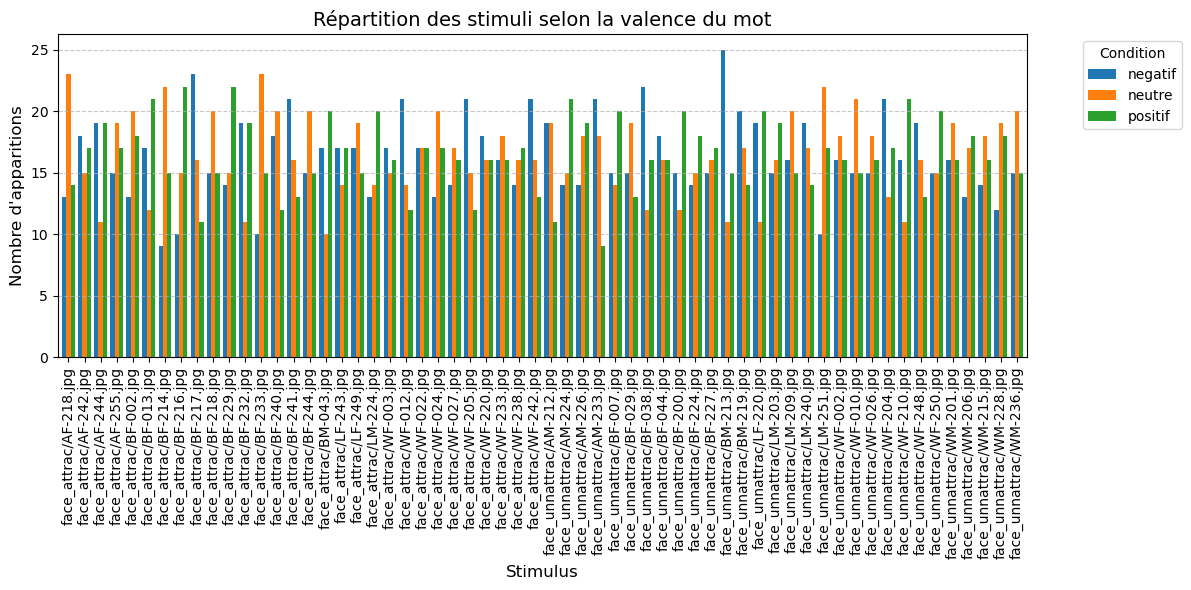

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Création du tableau de comptage par condition
stimulus_counts = (
    df.groupby(['stimilus', 'valence_mot'])
    .size()
    .unstack(fill_value=0)
)

# 2. Calcul de la moyenne de réponse (SANS reset_index pour garder l'alignement)
# On calcule la moyenne, ce qui donne une Série avec 'stimilus' en index
control = df[df['congruence'] == 'neutre']
reponse_moyenne = control.groupby('stimilus')['reponse_binary'].mean()

# On l'ajoute directement : Pandas aligne automatiquement via l'index 'stimilus'
stimulus_counts['reponse_mean'] = reponse_moyenne

# Affichage
print("Nombre d'apparitions et moyenne par stimulus :")
display(stimulus_counts)

# 3. Représentation graphique
plt.figure(figsize=(12, 6))
# On retire 'reponse_mean' juste pour le plot pour ne pas écraser les barres
stimulus_counts.drop(columns=['reponse_mean']).plot(kind='bar', ax=plt.gca(), width=0.8)

plt.title("Répartition des stimuli selon la valence du mot", fontsize=14)
plt.xlabel("Stimulus", fontsize=12)
plt.ylabel("Nombre d'apparitions", fontsize=12)
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Nombre de stimuli avec reponse_mean > 0.70 : 18

--- Analyse de la répartition des stimuli 'faciles' (> 0.70) ---


,Nombre d'apparitions
valence_mot,
neutre,313
negatif,299
positif,285



p-value du test d'uniformité : 0.5192
✅ OK : Les stimuli performants sont répartis de manière uniforme entre les conditions.


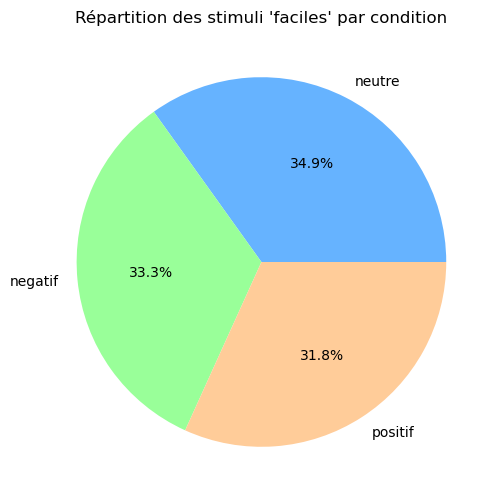

In [4]:
import pandas as pd
from scipy.stats import chisquare

# 1. Identifier les stimuli avec une moyenne de réussite > 0.70
# On réutilise le calcul de moyenne que nous avons fait précédemment
stats_stim = df.groupby('stimilus')['reponse_binary'].mean()
high_perf_stimuli = stats_stim[stats_stim > 0.60].index.tolist()

print(f"Nombre de stimuli avec reponse_mean > 0.70 : {len(high_perf_stimuli)}")

# 2. Filtrer le dataframe pour ne garder que ces stimuli
df_high_perf = df[df['stimilus'].isin(high_perf_stimuli)]

# 3. Compter leur répartition dans chaque condition de valence
distribution_by_condition = df_high_perf['valence_mot'].value_counts()

# 4. Test d'uniformité (Chi-deux) sur ces stimuli spécifiques
# Est-ce que ces stimuli "faciles" sont répartis équitablement (33% partout) ?
stat, p_value = chisquare(distribution_by_condition)

print("\n--- Analyse de la répartition des stimuli 'faciles' (> 0.70) ---")
display(distribution_by_condition.to_frame(name='Nombre d\'apparitions'))

print(f"\np-value du test d'uniformité : {p_value:.4f}")

if p_value < 0.05:
    print("❌ ALERTE : Les stimuli performants sont MAL DISTRIBUÉS.")
    print("Ils apparaissent significativement plus dans certaines conditions que d'autres.")
else:
    print("✅ OK : Les stimuli performants sont répartis de manière uniforme entre les conditions.")

# 5. Visualisation
distribution_by_condition.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title("Répartition des stimuli 'faciles' par condition")
plt.ylabel("")
plt.show()

Nombre total de réponses correctes par Condition et Attractivité :


valence_mot,negatif,neutre,positif
attractiveness_face,,,
Attractif,307.0,323.0,305.0
Unattractif,46.0,51.0,57.0


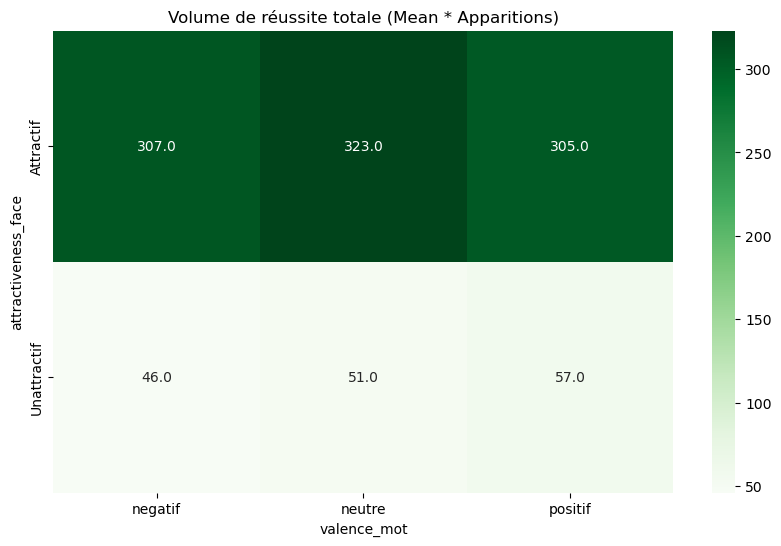

In [5]:
# 1. Calcul du nombre d'apparitions (N) par stimulus, condition et attractivité
count_map = df.groupby(['stimilus', 'valence_mot', 'attractiveness_face']).size().reset_index(name='n_apparitions')

# 2. Calcul de la moyenne de réussite par stimulus, condition et attractivité
mean_map = df.groupby(['stimilus', 'valence_mot', 'attractiveness_face'])['reponse_binary'].mean().reset_index(name='reponse_mean')

# 3. Fusion des deux et calcul de la valeur finale (le nombre de succès)
comparison_df = pd.merge(count_map, mean_map, on=['stimilus', 'valence_mot', 'attractiveness_face'])
comparison_df['total_correct_hits'] = comparison_df['reponse_mean'] * comparison_df['n_apparitions']

# 4. Pivot pour comparer les conditions et l'attractivité plus facilement
pivot_comparison = comparison_df.pivot_table(
    index='attractiveness_face', 
    columns='valence_mot', 
    values='total_correct_hits', 
    aggfunc='sum'
)

print("Nombre total de réponses correctes par Condition et Attractivité :")
display(pivot_comparison)

# 5. Visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_comparison, annot=True, fmt='.1f', cmap='Greens')
plt.title("Volume de réussite totale (Mean * Apparitions)")
plt.show()

In [6]:
# Condition neutre
control = df[df['congruence'] == 'neutre']

# Moyenne des réponses par stimulus
attractiveness = control.groupby('stimilus')['reponse_binary'].mean()

# Mapping attractivité
mapping = (attractiveness >= 0.5).map({True: 'attractive', False: 'non_attractive'})

print(mapping)

stimilus
face_attrac/AF-218.jpg           attractive
face_attrac/AF-242.jpg           attractive
face_attrac/AF-244.jpg       non_attractive
face_attrac/AF-255.jpg           attractive
face_attrac/BF-002.jpg           attractive
face_attrac/BF-013.jpg           attractive
face_attrac/BF-214.jpg       non_attractive
face_attrac/BF-216.jpg       non_attractive
face_attrac/BF-217.jpg           attractive
face_attrac/BF-218.jpg           attractive
face_attrac/BF-229.jpg       non_attractive
face_attrac/BF-232.jpg           attractive
face_attrac/BF-233.jpg           attractive
face_attrac/BF-240.jpg           attractive
face_attrac/BF-241.jpg           attractive
face_attrac/BF-244.jpg           attractive
face_attrac/BM-043.jpg           attractive
face_attrac/LF-243.jpg           attractive
face_attrac/LF-249.jpg           attractive
face_attrac/LM-224.jpg           attractive
face_attrac/WF-003.jpg           attractive
face_attrac/WF-012.jpg           attractive
face_attrac/WF-022.jpg 

In [7]:
corrected_data = df.copy()
# 1. On calcule les stats séparément
stats_df = (
    corrected_data
    .groupby('stimilus')['reponse_binary']
    .mean()
    .reset_index(name='reponse_mean')
)

# 2. On fusionne avec ton count_df existant
count_df = (
    control
    .groupby('stimilus')
    .size()
    .reset_index(name='n_evaluations')
)

final_df = count_df.merge(stats_df, on='stimilus', how='left')
final_df

,stimilus,n_evaluations,reponse_mean
0,face_attrac/AF-218.jpg,23,0.700000
1,face_attrac/AF-242.jpg,15,0.600000
2,face_attrac/AF-244.jpg,11,0.428571
3,face_attrac/AF-255.jpg,19,0.686275
4,face_attrac/BF-002.jpg,20,0.764706
5,face_attrac/BF-013.jpg,12,0.760000
6,face_attrac/BF-214.jpg,22,0.456522
7,face_attrac/BF-216.jpg,15,0.404255
8,face_attrac/BF-217.jpg,16,0.660000
9,face_attrac/BF-218.jpg,20,0.740000


In [8]:
# Mapping attractivité
corrected_data['attractiveness_face'] = corrected_data['stimilus'].map(mapping)

# Gestion des stimuli absents de la condition neutre
corrected_data['attractiveness_face'] = corrected_data['attractiveness_face'].fillna('unknown')

# Variable correct (en excluant les unknown)
corrected_data['correct'] = (
    ((corrected_data['attractiveness_face'] == 'attractive') & (corrected_data['reponse_binary'] == 1)) |
    ((corrected_data['attractiveness_face'] == 'non_attractive') & (corrected_data['reponse_binary'] == 0))
).astype(int)

In [9]:
corrected_data

,id,stimilus,valence_mot,attractiveness_face,congruence,response,reponse_binary,correct,rt
0,9at0mps0,face_attrac/WF-233.jpg,positif,attractive,congruent,Non attractif,0,0,0.223
1,9at0mps0,face_unnattrac/WF-026.jpg,positif,non_attractive,incongruent,Attractif,1,0,0.295
2,9at0mps0,face_unnattrac/BM-219.jpg,negatif,non_attractive,congruent,Non attractif,0,1,0.109
3,9at0mps0,face_unnattrac/WM-215.jpg,neutre,non_attractive,neutre,Attractif,1,0,0.185
4,9at0mps0,face_unnattrac/LM-251.jpg,positif,non_attractive,incongruent,Attractif,1,0,1.067
...,...,...,...,...,...,...,...,...,...
2949,66o3mn1h,face_unnattrac/LM-209.jpg,negatif,non_attractive,congruent,Non attractif,0,1,0.758
2950,66o3mn1h,face_attrac/WF-238.jpg,negatif,attractive,incongruent,Attractif,1,1,1.361
2951,66o3mn1h,face_attrac/BF-244.jpg,neutre,attractive,neutre,Non attractif,0,0,0.735
2952,66o3mn1h,face_unnattrac/BM-219.jpg,neutre,non_attractive,neutre,Attractif,1,0,1.164


### Detect the outliers

Visage précédé d'un mot neutre. En théorie, 100% de précision:

In [10]:
# We take all the rows where the congruence condition is neutral
control = corrected_data[corrected_data['congruence'] == 'neutre']
# Pourcentage of correct answer per id
control_pourcentage = control.groupby('id')['correct'].mean()
# Get the index of the id that got a pourcentage of correct answer below 70%
id_outliers = control_pourcentage[control_pourcentage <= .0].index
# If we want to take out some index
id_outliers = id_outliers.append(pd.Index(['imgzntah']))

In [11]:
# Create a DataFrame without outliers
data_without_outliers= corrected_data[~corrected_data['id'].isin(id_outliers)]
# To verify
data_without_outliers[(data_without_outliers['valence_mot']=='positif') & (data_without_outliers['attractiveness_face'] == 'attractive') ].groupby('id')['correct'].mean().reset_index(name='%')

,id,%
0,1v24kyhs,0.714286
1,2jp4ppt2,0.625000
2,3ofn5wde,1.000000
3,4hgpolkf,0.444444
4,66o3mn1h,0.714286
5,6ipwu4mk,0.250000
6,71f898fp,0.375000
7,7eih1i0q,0.600000
8,7re7u25l,0.500000
9,7rngwvq4,0.888889


In [12]:
attractiveness_levels = ['attractive', 'non_attractive']
valence_levels = ['positif', 'neutre','negatif']

for attr in attractiveness_levels:
    for val in valence_levels:
        mean_value = data_without_outliers[
            (data_without_outliers['attractiveness_face'] == attr) &
            (data_without_outliers['valence_mot'] == val)
        ]['correct'].mean()

        print(f"Poucentage de réponse correct pour visage {attr}, mot {val} : {mean_value*100:.3f}")

Poucentage de réponse correct pour visage attractive, mot positif : 63.614
Poucentage de réponse correct pour visage attractive, mot neutre : 69.484
Poucentage de réponse correct pour visage attractive, mot negatif : 65.566
Poucentage de réponse correct pour visage non_attractive, mot positif : 83.957
Poucentage de réponse correct pour visage non_attractive, mot neutre : 86.447
Poucentage de réponse correct pour visage non_attractive, mot negatif : 86.142


In [13]:
attractiveness_levels = ['attractive', 'non_attractive']
valence_levels = ['positif', 'neutre','negatif']

for attr in attractiveness_levels:
    for val in valence_levels:
        mean_value = data_without_outliers[
            (data_without_outliers['attractiveness_face'] == attr) &
            (data_without_outliers['valence_mot'] == val)
        ]['correct'].mean()

        print(f"Temps de réponses moyen pour visage {attr}, mot {val} : {mean_value:.3f}")

Temps de réponses moyen pour visage attractive, mot positif : 0.636
Temps de réponses moyen pour visage attractive, mot neutre : 0.695
Temps de réponses moyen pour visage attractive, mot negatif : 0.656
Temps de réponses moyen pour visage non_attractive, mot positif : 0.840
Temps de réponses moyen pour visage non_attractive, mot neutre : 0.864
Temps de réponses moyen pour visage non_attractive, mot negatif : 0.861


In [14]:
import scipy.stats as sc
a=data_without_outliers[(data_without_outliers['attractiveness_face'] == 'Attractif') & (data_without_outliers['valence_mot'] == 'positif')]['correct']
b=data_without_outliers[(data_without_outliers['attractiveness_face'] == 'Attractif') & (data_without_outliers['valence_mot'] == 'neutre')]['correct']
sc.ttest_ind(a,b)

c:\Users\Charles\anaconda3\envs\sciprog\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

--- IMPACT RÉEL DES MOTS (Déviation par rapport à la baseline) ---
Un score de 0 signifie aucun changement par rapport au neutre.


valence_mot,negatif,neutre,positif
attractiveness_face,,,
Attractif,-1.222684,2.447385e-16,-0.399880
Unattractif,-1.218360,1.576382e-16,1.761554


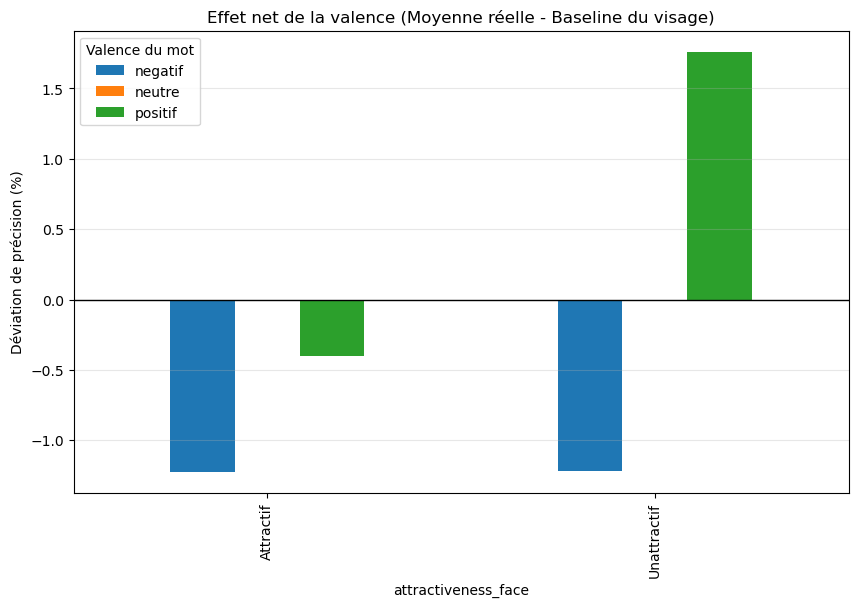

In [15]:
# 1. On prépare la baseline par stimulus (moyenne en condition neutre)
# On s'assure d'utiliser les données filtrées sans outliers
baseline = df[df['valence_mot'] == 'neutre'].groupby('stimilus')['reponse_binary'].mean()

# 2. On crée une fonction pour soustraire cette baseline
def calculate_net_effect(row):
    # On récupère la baseline du stimulus en question
    stim_baseline = baseline.get(row['stimilus'], 0)
    return row['reponse_binary'] - stim_baseline

# 3. On applique ce calcul sur tout le dataframe
df['net_effect'] = df.apply(calculate_net_effect, axis=1)

# 4. On calcule maintenant les moyennes de cet "effet net" par condition et attractivité
net_impact_results = df.groupby(['attractiveness_face', 'valence_mot'])['net_effect'].mean() * 100

print("--- IMPACT RÉEL DES MOTS (Déviation par rapport à la baseline) ---")
print("Un score de 0 signifie aucun changement par rapport au neutre.")
display(net_impact_results.unstack())

# 5. Visualisation de l'effet pur
plt.figure(figsize=(10, 6))
net_impact_results.unstack().plot(kind='bar', ax=plt.gca())
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title("Effet net de la valence (Moyenne réelle - Baseline du visage)")
plt.ylabel("Déviation de précision (%)")
plt.legend(title="Valence du mot")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [18]:
from scipy import stats

print("--- Comparaison des déviations par rapport au Neutre (0) ---")

for attr in ['Attractif', 'Unattractif']:
    for valence in ['positif', 'negatif']:
        # On récupère les scores de déviation pour ce groupe précis
        group_data = df[(df['attractiveness_face'] == attr) & 
                        (df['valence_mot'] == valence)]['net_effect'].dropna()
        
        # Test t à un échantillon (One-sample t-test)
        # On compare la moyenne de la déviation à 0 (qui représente le neutre)
        t_stat, p_val = stats.ttest_1samp(group_data, 0)
        
        status = "✅ SIGNIFICATIF" if p_val < 0.05 else "❌ NON significatif"
        
        print(f"\nGroupe: {attr} | Valence: {valence}")
        print(f"- Déviation moyenne : {group_data.mean()*100:.2f}%")
        print(f"- p-value : {p_val:.4f} ({status})")

--- Comparaison des déviations par rapport au Neutre (0) ---

Groupe: Attractif | Valence: positif
- Déviation moyenne : -0.40%
- p-value : 0.8557 (❌ NON significatif)

Groupe: Attractif | Valence: negatif
- Déviation moyenne : -1.22%
- p-value : 0.5829 (❌ NON significatif)

Groupe: Unattractif | Valence: positif
- Déviation moyenne : 1.76%
- p-value : 0.2312 (❌ NON significatif)

Groupe: Unattractif | Valence: negatif
- Déviation moyenne : -1.22%
- p-value : 0.3671 (❌ NON significatif)
